# Latent Diffusion / Flow — EMNIST
**Project: Latent Diffusion on EMNIST**

This notebook trains a Denoiser/Flow model in the latent space learned by the VAE.
It loads the trained encoder from `vae_best.ckpt` and keeps it frozen during training.
The decoder is loaded separately and used only at generation time.

> Run on: Runtime → Change Runtime Type → T4 GPU

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## 2. VAE architecture (copied from VAE_EMNIST.ipynb)

These classes must match exactly what was used to train the VAE,
otherwise `load_state_dict` will fail.
Both 2-block and 3-block variants are defined; the checkpoint
stores which architecture was used.


In [2]:
class ReshapeToImage(nn.Module):
    def forward(self, x):
        return x.view(-1, 1, 28, 28)


# ── 2-block architecture ───────────────────────────────────────────

class Encoder2(nn.Module):
    def __init__(self, latent_dim, use_diff_sigma_E):
        super().__init__()
        self.conv = nn.Sequential(
            ReshapeToImage(),
            nn.Conv2d(1,  32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(64 * 7 * 7, latent_dim)
        logvar_out     = latent_dim if use_diff_sigma_E else 1
        self.fc_logvar = nn.Linear(64 * 7 * 7, logvar_out)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder2(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,  1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
            nn.Flatten(),
        )

    def forward(self, z):
        return self.net(z)


# ── 3-block architecture ───────────────────────────────────────────

class Encoder3(nn.Module):
    def __init__(self, latent_dim, use_diff_sigma_E):
        super().__init__()
        self.conv = nn.Sequential(
            ReshapeToImage(),
            nn.Conv2d(1,   32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32,  64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(128 * 3 * 3, latent_dim)
        logvar_out     = latent_dim if use_diff_sigma_E else 1
        self.fc_logvar = nn.Linear(128 * 3 * 3, logvar_out)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder3(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128 * 3 * 3),
            nn.ReLU(),
            nn.Unflatten(1, (128, 3, 3)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2,
                               padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,   1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
            nn.Flatten(),
        )

    def forward(self, z):
        return self.net(z)


# ── Architecture factory ───────────────────────────────────────────

_ARCHITECTURES = {
    '2blocks': (Encoder2, Decoder2),
    '3blocks': (Encoder3, Decoder3),
}

def get_encoder_decoder(arch, latent_dim, use_diff_sigma_E):
    EncoderCls, DecoderCls = _ARCHITECTURES[arch]
    return EncoderCls(latent_dim, use_diff_sigma_E), DecoderCls(latent_dim)


## 3. Load encoder and decoder from VAE checkpoint

In [3]:
VAE_CKPT = 'training_checkpoints/vae_best.ckpt'

ckpt = torch.load(VAE_CKPT, map_location=device)

LATENT_DIM       = ckpt['latent_dim']
USE_DIFF_SIGMA_E = ckpt['use_diff_sigma_E']
ARCH             = ckpt.get('arch', '2blocks')   # backward compat

encoder, decoder = get_encoder_decoder(ARCH, LATENT_DIM, USE_DIFF_SIGMA_E)
encoder = encoder.to(device)
encoder.load_state_dict(ckpt['encoder'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad_(False)

decoder = decoder.to(device)
decoder.load_state_dict(ckpt['decoder'])
decoder.eval()
for p in decoder.parameters():
    p.requires_grad_(False)

print(f'Loaded VAE checkpoint from epoch {ckpt["epoch"]} '
      f'(test loss {ckpt["test_loss"]:.4f})')
print(f'LATENT_DIM = {LATENT_DIM}, ARCH = {ARCH}')


Loaded VAE checkpoint from epoch 77 (test loss 134.1707)
LATENT_DIM = 32, ARCH = 3blocks


## 4. Sanity check — encode a batch and decode it back

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

EMNIST_SPLIT = ckpt.get('emnist_split', 'byclass')

transform = transforms.ToTensor()
test_dataset = datasets.EMNIST(
    root='data', split=EMNIST_SPLIT, train=False,
    transform=transform, download=True,
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

images, labels = next(iter(test_loader))
x = images.view(images.size(0), -1).to(device)  # (B, 784)

with torch.no_grad():
    mu, _ = encoder(x)
    x_hat = decoder(mu)

print(f'Input shape  : {x.shape}')
print(f'Latent shape : {mu.shape}')   # (B, LATENT_DIM)
print(f'Output shape : {x_hat.shape}')
print(f'Latent stats  — mean: {mu.mean():.3f}  std: {mu.std():.3f}')

Input shape  : torch.Size([64, 784])
Latent shape : torch.Size([64, 32])
Output shape : torch.Size([64, 784])
Latent stats  — mean: -0.001  std: 0.727


## 5. Latent Diffusion Model (Denoiser)

In [5]:
import math
import torch # Added for robustness
import torch.nn as nn # Added for robustness

class LatentDenoiser(nn.Module):
    def __init__(self, latent_dim, num_classes, time_embedding_dim=256, hidden_dim=256, label_embedding_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.time_embedding_dim = time_embedding_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.label_embedding_dim = label_embedding_dim

        # Time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, time_embedding_dim * 4),
            nn.GELU(),
            nn.Linear(time_embedding_dim * 4, time_embedding_dim)
        )

        # Label embedding
        self.label_emb = nn.Embedding(num_classes, label_embedding_dim)

        # Input projection + initial layer
        # Now includes latent_dim + time_embedding_dim + label_embedding_dim
        self.proj_in = nn.Linear(latent_dim + time_embedding_dim + label_embedding_dim, hidden_dim)

        # Downsampling blocks with residual connections
        self.down1 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2)
        )
        self.down_res1 = nn.Linear(hidden_dim, hidden_dim * 2) # For skip connection

        self.down2 = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim * 4)
        )
        self.down_res2 = nn.Linear(hidden_dim * 2, hidden_dim * 4) # For skip connection

        # Bottleneck
        self.mid = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim * 4)
        )

        # Upsampling blocks with residual connections (from skip + current layer)
        # Input is concat of mid output and skip from down2
        self.up1 = nn.Sequential(
            nn.Linear(hidden_dim * 4 + hidden_dim * 4, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2)
        )
        self.up_res1 = nn.Linear(hidden_dim * 4 + hidden_dim * 4, hidden_dim * 2) # For skip connection

        # Input is concat of up1 output and skip from down1
        self.up2 = nn.Sequential(
            nn.Linear(hidden_dim * 2 + hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.up_res2 = nn.Linear(hidden_dim * 2 + hidden_dim * 2, hidden_dim) # For skip connection

        # Output layer
        self.proj_out = nn.Linear(hidden_dim, latent_dim)

    # Added gelu activation here, as it was missing in the original code for some residual paths
    def gelu(self, x):
        return nn.functional.gelu(x)

    def forward(self, z, t, labels): # Added labels as input
        # z: latent vector (batch_size, latent_dim)
        # t: time step (batch_size,)
        # labels: class labels (batch_size,)

        # Create time embedding
        t_embed = self.time_embedding(t)
        t_embed = self.time_mlp(t_embed)

        # Create label embedding
        label_embed = self.label_emb(labels)

        # Concatenate latent vector, time embedding, and label embedding
        x = torch.cat([z, t_embed, label_embed], dim=1)
        x = self.proj_in(x) # (B, hidden_dim)

        # Downsampling path
        # Block 1
        h1 = x
        x = self.down1(x) + self.down_res1(h1) # Residual connection
        x = self.gelu(x)
        skip1 = x # Store for skip connection

        # Block 2
        h2 = x
        x = self.down2(x) + self.down_res2(h2) # Residual connection
        x = self.gelu(x)
        skip2 = x # Store for skip connection

        # Bottleneck
        x = self.mid(x) + x # Residual connection
        x = self.gelu(x) # Added missing activation here

        # Upsampling path (with skip connections)
        # Block 1
        x_up1_input = torch.cat([x, skip2], dim=1) # Concatenate with skip from down2
        h3 = x_up1_input
        x = self.up1(x_up1_input) + self.up_res1(h3) # Residual connection
        x = self.gelu(x)

        # Block 2
        x_up2_input = torch.cat([x, skip1], dim=1) # Concatenate with skip from down1
        h4 = x_up2_input
        x = self.up2(x_up2_input) + self.up_res2(h4) # Residual connection
        x = self.gelu(x)

        # Output
        x = self.proj_out(x)

        return x

    def time_embedding(self, t):
        # Sinusoidal positional embeddings for time
        half_dim = self.time_embedding_dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :] # Reshape t to (batch_size, 1) for broadcasting
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# EMNIST 'byclass' split has 62 classes (0-9, A-Z, a-z)
NUM_EMNIST_CLASSES = 62
latent_denoiser = LatentDenoiser(LATENT_DIM, num_classes=NUM_EMNIST_CLASSES, hidden_dim=LATENT_DIM * 3.2).to(device) # Increased hidden_dim for better capacity
print(f'Latent Denoiser model created with {sum(p.numel() for p in latent_denoiser.parameters())} parameters.')

Latent Denoiser model created with 2500256 parameters.


In [6]:
import math

def linear_beta_schedule(timesteps):
    scale = 1000 / timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    # Changed dtype to torch.float32 to match model's expected input
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float32)

def cosine_beta_schedule(timesteps, s=0.008):
    """cosine schedule as proposed in https://arxiv.org/abs/2102.09672"""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32) # Changed dtype to float32
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

TIMESTEPS = 1000  # Number of diffusion steps - Standardized to 1000 for better results
b_t = linear_beta_schedule(TIMESTEPS).to(device) # Or use cosine_beta_schedule

a_t = 1. - b_t
alpha_bar_t = torch.cumprod(a_t, dim=0)

# Helper functions for diffusion process
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t).to(t.device)
    # Explicitly reshape to (batch_size, 1) to ensure broadcasting with latent vectors
    return out.view(batch_size, 1)

def get_noisy_latent(x_start, t, alpha_bar_t, device):
    # Forward diffusion (sample from q(z_t | z_0))
    sqrt_alpha_bar_t = extract(torch.sqrt(alpha_bar_t), t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(torch.sqrt(1. - alpha_bar_t), t, x_start.shape)
    epsilon = torch.randn_like(x_start, device=device)
    noisy_latent = sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * epsilon
    return noisy_latent, epsilon

print(f'Noise schedule (betas) initialized with {TIMESTEPS} timesteps.')

Noise schedule (betas) initialized with 1000 timesteps.


### Training the Latent Denoiser

Now that the `LatentDenoiser` model and noise schedules are defined, the next steps involve training the model.

1.  **Define Loss Function:** A common loss function for diffusion models is Mean Squared Error (MSE) between the predicted noise and the actual noise added.
2.  **Optimizer:** Choose an optimizer (e.g., Adam) and learning rate.
3.  **Training Loop:**
    *   For each training step:
        *   Sample a batch of latent vectors `z_0` from the VAE encoder.
        *   Sample random timesteps `t`.
        *   Generate noisy latent vectors `z_t` and the actual noise `epsilon` using `get_noisy_latent`.
        *   Pass `z_t` and `t` to the `LatentDenoiser` to predict the noise `epsilon_pred`.
        *   Calculate the loss: `MSE(epsilon_pred, epsilon)`.
        *   Perform backpropagation and update model parameters.
4.  **Evaluation and Generation:** Periodically evaluate the model by generating new samples from random noise using the reverse diffusion process.

## 6. Training Configuration and Loop

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

# Configuration for training
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

# Loss function: Mean Squared Error (MSE) between predicted noise and actual noise
loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(latent_denoiser.parameters(), lr=LEARNING_RATE)

# Load EMNIST dataset again for training the denoiser
# We'll use the training split to get a diverse set of latents
transform = transforms.ToTensor()
train_dataset = datasets.EMNIST(
    root='data', split=EMNIST_SPLIT, train=True,
    transform=transform, download=True,
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Training configuration set: BATCH_SIZE={BATCH_SIZE}, LEARNING_RATE={LEARNING_RATE}, NUM_EPOCHS={NUM_EPOCHS}")
print(f"Using {len(train_dataset)} training samples.")


Training configuration set: BATCH_SIZE=64, LEARNING_RATE=0.0001, NUM_EPOCHS=10
Using 697932 training samples.


In [8]:
import torch # Added for robustness
from tqdm import tqdm # Added for robustness

print("Starting training of Latent Denoiser...")

training_losses = [] # List to store average loss per epoch

for epoch in range(NUM_EPOCHS):
    latent_denoiser.train() # Set model to training mode
    total_loss = 0
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_0 = images.view(images.size(0), -1).to(device) # Original images
        labels = labels.to(device) # Move labels to device

        # Get latent representation from pre-trained VAE encoder
        with torch.no_grad(): # VAE encoder is frozen
            mu_0, _ = encoder(x_0)

        # Sample time step t for each latent in the batch
        t = torch.randint(0, TIMESTEPS, (mu_0.shape[0],), device=device).long()

        # Add noise to the latent vectors
        noisy_latent, epsilon_true = get_noisy_latent(mu_0, t, alpha_bar_t, device)

        # Predict noise using the latent denoiser, passing labels
        epsilon_pred = latent_denoiser(noisy_latent, t, labels)

        # Calculate loss and update model
        loss = loss_fn(epsilon_pred, epsilon_true)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    training_losses.append(avg_loss) # Store the average loss
    print(f"Epoch {epoch+1} finished, Average Loss: {avg_loss:.4f}")

    # Optional: Add evaluation and sampling code here to see progress

print("Training complete.")

Starting training of Latent Denoiser...


Epoch 1/10: 100%|██████████| 10906/10906 [02:05<00:00, 86.94it/s] 


Epoch 1 finished, Average Loss: 0.2120


Epoch 2/10: 100%|██████████| 10906/10906 [02:04<00:00, 87.70it/s] 


Epoch 2 finished, Average Loss: 0.1727


...

Epoch 8 finished, Average Loss: 0.1489


Epoch 9/10: 100%|██████████| 10906/10906 [02:09<00:00, 84.08it/s] 


Epoch 9 finished, Average Loss: 0.1482


Epoch 10/10: 100%|██████████| 10906/10906 [02:16<00:00, 79.95it/s] 

Epoch 10 finished, Average Loss: 0.1470
Training complete.


In [9]:
DENOISER_CKPT = 'latent_denoiser_best.ckpt'

# Save the model checkpoint after training is complete
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': latent_denoiser.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_loss': training_losses[-1], # Save the last average loss
    'latent_dim': LATENT_DIM,
    'num_emnist_classes': NUM_EMNIST_CLASSES,
    'hidden_dim': latent_denoiser.hidden_dim,
    'time_embedding_dim': latent_denoiser.time_embedding_dim,
    'label_embedding_dim': latent_denoiser.label_embedding_dim,
    'timesteps': TIMESTEPS,
    'training_losses': training_losses # Save the history of training losses
}, DENOISER_CKPT)

print(f"Latent Denoiser model and optimizer state saved to '{DENOISER_CKPT}'")

Latent Denoiser model and optimizer state saved to 'latent_denoiser_best.ckpt'


### Plots of Training Error

Let's visualize the denoiser's training error (loss) over the epochs to understand the model's convergence.

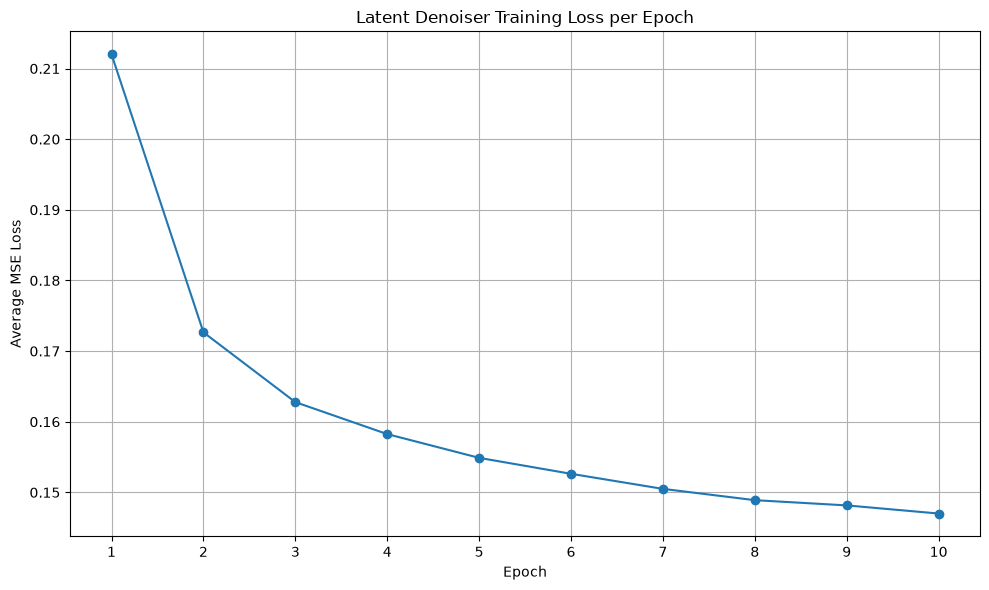

Plot of training loss over epochs displayed.


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker='o', linestyle='-')
plt.title('Latent Denoiser Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.grid(True)
plt.xticks(range(1, len(training_losses) + 1))
plt.tight_layout()
plt.show()

print("Plot of training loss over epochs displayed.")

In [10]:
import torch # Added for robustness
from tqdm import tqdm # Added for robustness

@torch.no_grad()
def p_sample(model, x, t, t_index, betas, labels): # Added labels as input
    # Helper function for reverse diffusion step (from DDPM paper)

    # Calculate coefficients
    sqrt_recip_alphas_overall = 1.0 / torch.sqrt(1.0 - betas) # (TIMESTEPS,)
    # Extract the batch-specific values and reshape for broadcasting
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas_overall, t, x.shape) # Now guaranteed (batch_size, 1)

    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alpha_bar_t), t, x.shape)

    # Predict noise
    pred_noise = model(x, t, labels) # Pass labels to the model

    # Calculate x_0 prediction (needed for reparametrization)
    x_0_pred = (x - sqrt_one_minus_alphas_cumprod_t * pred_noise) / extract(torch.sqrt(alpha_bar_t), t, x.shape)

    # Calculate mean and variance for reverse step
    mean = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * pred_noise)

    # If t is 0, we don't add noise
    if t_index == 0:
        return mean
    else:
        posterior_variance_t = betas_t
        noise = torch.randn_like(x)
        return mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def p_sample_loop(model, shape, timesteps, device, labels): # Added labels as input
    # Full sampling loop
    img = torch.randn(shape, device=device) # Start with pure noise

    for i in tqdm(reversed(range(0, timesteps)), desc='Sampling', total=timesteps):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i, b_t, labels) # Pass labels to p_sample

    return img

@torch.no_grad()
def generate_samples(model, vae_decoder, num_samples, latent_dim, timesteps, device, conditioning_labels=None): # Added conditioning_labels
    model.eval()
    vae_decoder.eval()

    if conditioning_labels is None:
        # If no specific labels are provided, generate random labels for sampling
        conditioning_labels = torch.randint(0, NUM_EMNIST_CLASSES, (num_samples,), device=device, dtype=torch.long)
    elif isinstance(conditioning_labels, int):
        # If a single label is provided, create a batch of that label
        conditioning_labels = torch.full((num_samples,), conditioning_labels, device=device, dtype=torch.long)
    else:
        # Ensure conditioning_labels are on the correct device and type
        conditioning_labels = conditioning_labels.to(device).long()
        if conditioning_labels.shape[0] != num_samples:
            raise ValueError(f"Number of conditioning labels ({conditioning_labels.shape[0]}) must match num_samples ({num_samples})")

    # Sample latent vectors from the diffusion model
    sampled_latents = p_sample_loop(model, (num_samples, latent_dim), timesteps, device, conditioning_labels) # Pass conditioning_labels

    # Decode latents into images using the VAE decoder
    generated_images = vae_decoder(sampled_latents)

    return generated_images

print("Sampling functions 'p_sample', 'p_sample_loop', and 'generate_samples' defined.")

Sampling functions 'p_sample', 'p_sample_loop', and 'generate_samples' defined.


Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 457.05it/s]


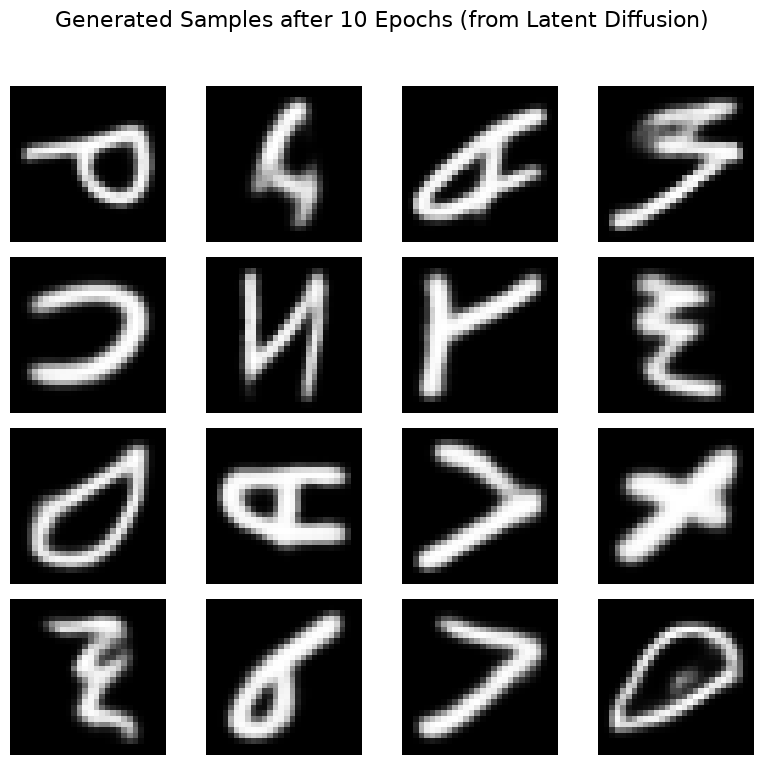

Generated and displayed 16 sample images.


In [11]:
import matplotlib.pyplot as plt

# Example: Generate a few samples (after some training epochs)
# Note: It's recommended to run this after the denoiser has trained for a while.

NUM_SAMPLES_TO_GENERATE = 16

# Ensure the denoiser is in evaluation mode
latent_denoiser.eval()

# Generate images
generated_images = generate_samples(
    latent_denoiser, decoder, NUM_SAMPLES_TO_GENERATE, LATENT_DIM, TIMESTEPS, device
)

# Visualize the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    img = generated_images[i].cpu().view(28, 28).numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.suptitle(f'Generated Samples after {epoch+1} Epochs (from Latent Diffusion)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Generated and displayed {NUM_SAMPLES_TO_GENERATE} sample images.")


In [12]:
import torch # Added for robustness
from tqdm import tqdm # Added for robustness

@torch.no_grad()
def p_sample(model, x, t, t_index, betas, labels): # Added labels as input
    # Helper function for reverse diffusion step (from DDPM paper)

    # Calculate coefficients
    sqrt_recip_alphas_overall = 1.0 / torch.sqrt(1.0 - betas) # (TIMESTEPS,)
    # Extract the batch-specific values and reshape for broadcasting
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas_overall, t, x.shape) # Now guaranteed (batch_size, 1)

    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alpha_bar_t), t, x.shape)

    # Predict noise
    pred_noise = model(x, t, labels) # Pass labels to the model

    # Calculate x_0 prediction (needed for reparametrization)
    x_0_pred = (x - sqrt_one_minus_alphas_cumprod_t * pred_noise) / extract(torch.sqrt(alpha_bar_t), t, x.shape)

    # Calculate mean and variance for reverse step
    mean = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * pred_noise)

    # If t is 0, we don't add noise
    if t_index == 0:
        return mean
    else:
        posterior_variance_t = betas_t
        noise = torch.randn_like(x)
        return mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def p_sample_loop(model, shape, timesteps, device, labels): # Added labels as input
    # Full sampling loop
    img = torch.randn(shape, device=device) # Start with pure noise

    for i in tqdm(reversed(range(0, timesteps)), desc='Sampling', total=timesteps):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i, b_t, labels) # Pass labels to p_sample

    return img

@torch.no_grad()
def generate_samples(model, vae_decoder, num_samples, latent_dim, timesteps, device, conditioning_labels=None): # Added conditioning_labels
    model.eval()
    vae_decoder.eval()

    if conditioning_labels is None:
        # If no specific labels are provided, generate random labels for sampling
        conditioning_labels = torch.randint(0, NUM_EMNIST_CLASSES, (num_samples,), device=device, dtype=torch.long)
    elif isinstance(conditioning_labels, int):
        # If a single label is provided, create a batch of that label
        conditioning_labels = torch.full((num_samples,), conditioning_labels, device=device, dtype=torch.long)
    else:
        # Ensure conditioning_labels are on the correct device and type
        conditioning_labels = conditioning_labels.to(device).long()
        if conditioning_labels.shape[0] != num_samples:
            raise ValueError(f"Number of conditioning labels ({conditioning_labels.shape[0]}) must match num_samples ({num_samples})")

    # Sample latent vectors from the diffusion model
    sampled_latents = p_sample_loop(model, (num_samples, latent_dim), timesteps, device, conditioning_labels) # Pass conditioning_labels

    # Decode latents into images using the VAE decoder
    generated_images = vae_decoder(sampled_latents)

    return generated_images

print("Sampling functions 'p_sample', 'p_sample_loop', and 'generate_samples' defined.")

Sampling functions 'p_sample', 'p_sample_loop', and 'generate_samples' defined.


Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 454.68it/s]


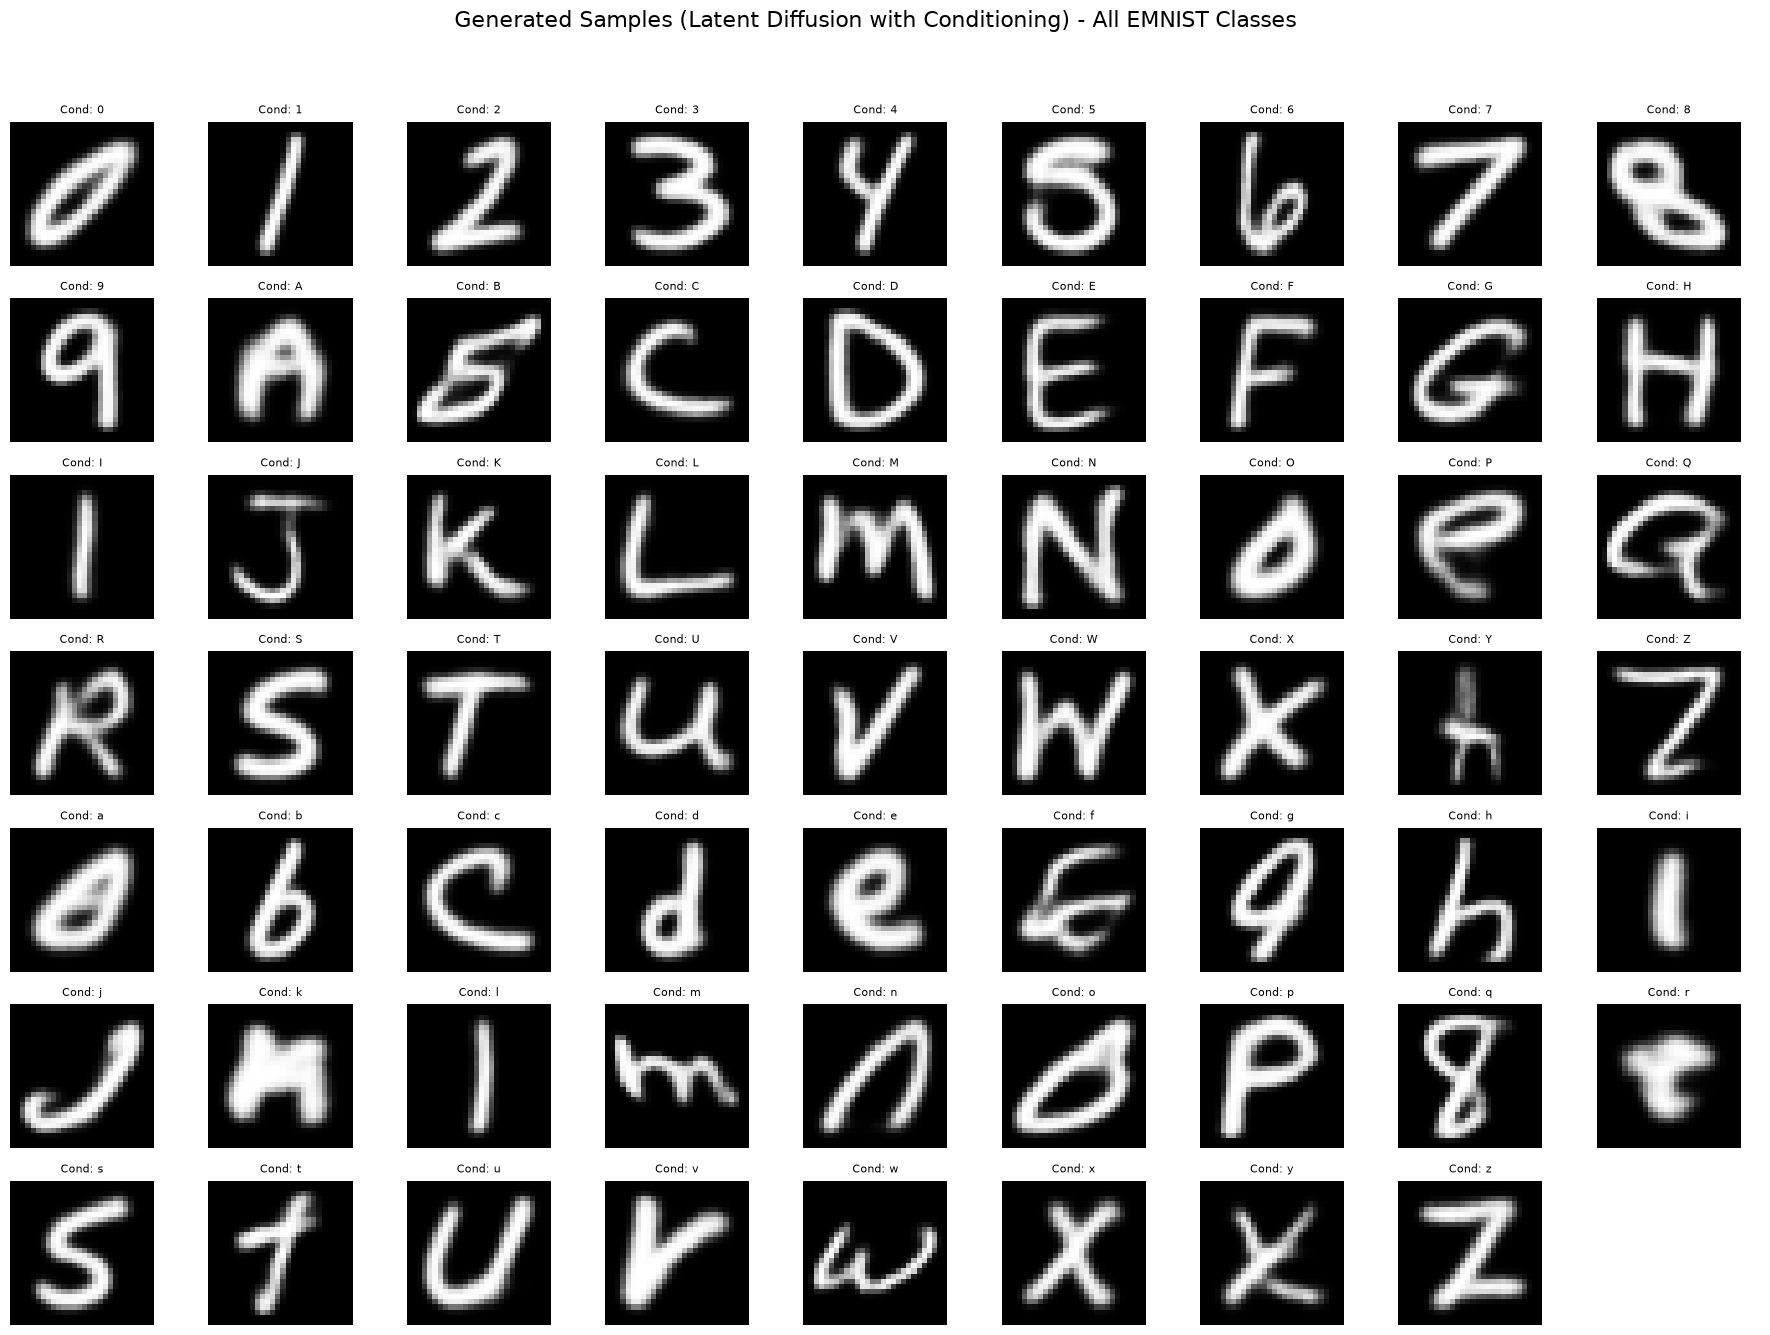

Generated and displayed 62 conditioned sample images (one for each class).


In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np # Import numpy for array manipulation

# Function to fix EMNIST image orientation
def fix_emnist_image(img: np.ndarray) -> np.ndarray:
    """Undo EMNIST's built-in 90° CW rotation + horizontal mirror (visualization only)."""
    return np.rot90(np.fliplr(img))

# Ensure the denoiser is in evaluation mode
latent_denoiser.eval()

# Generate one sample for each EMNIST class
# EMNIST 'byclass' has 62 classes (0-9, A-Z, a-z).
# We will create conditioning labels for each class from 0 to 61.
NUM_SAMPLES_TO_GENERATE = NUM_EMNIST_CLASSES # 62 samples, one for each class

# Create conditioning labels for all classes (0 to 61)
conditioning_labels = torch.arange(NUM_EMNIST_CLASSES, device=device, dtype=torch.long)

# Generate images with conditioning
generated_images_conditioned = generate_samples(
    latent_denoiser, decoder, NUM_SAMPLES_TO_GENERATE, LATENT_DIM, TIMESTEPS, device, conditioning_labels
)

# Visualize the generated images
# We need a grid large enough for 62 samples, e.g., 7x9 = 63 cells.
n_cols = 9
n_rows = (NUM_EMNIST_CLASSES + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
axes = axes.flatten()

# Function to map EMNIST class ID to character
def get_emnist_char(class_id):
    if 0 <= class_id <= 9:
        return str(class_id)
    elif 10 <= class_id <= 35:
        return chr(ord('A') + class_id - 10)
    elif 36 <= class_id <= 61:
        return chr(ord('a') + class_id - 36)
    else:
        return '?'

for i in range(NUM_SAMPLES_TO_GENERATE):
    img_raw = generated_images_conditioned[i].cpu().view(28, 28).numpy()
    img_fixed = fix_emnist_image(img_raw) # Apply the fix_emnist_image function
    ax = axes[i]
    ax.imshow(img_fixed, cmap='gray') # Display the fixed image
    ax.axis('off')
    char_label = get_emnist_char(conditioning_labels[i].item())
    ax.set_title(f'Cond: {char_label}', fontsize=8)

# Turn off any unused subplots
for j in range(NUM_SAMPLES_TO_GENERATE, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Generated Samples (Latent Diffusion with Conditioning) - All EMNIST Classes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Generated and displayed {NUM_SAMPLES_TO_GENERATE} conditioned sample images (one for each class).")